# Evaluation of Motion-Smoothing Filters for Robotic Pan-Tilt Head Tracking

### Research Question
How do different motion-smoothing filter architectures and parameter configurations affect the dynamic response, tracking latency, and smoothness of a 2-DOF robotic pan-tilt head under varied input motion profiles?

### Motivation 
Teleoperation and head-tracking interfaces (such as VR headsets, vision-based pose estimators, or IMUs) inherently introduce high-frequency noise, latency, and sudden trajectory jumps into raw command streams. This is especially common in RoboCup@Home tasks, where there is much visual clutter in the arena. Direct deployment of unfiltered tracking data to physical pan-tilt servos causes mechanical vibration, excessive motor strain, jittery motion, and poor user tracking fidelity. The objective of filtering is to suppress high-frequency noise and mechanical shock while minimizing phase lag and transient overshoot.

### 2. Experimental Overview

| Independent Variable | Description | Examples |
|---|---|---|
| **Filter Architecture** | Filter algorithms configured in the ROS 2 control loop | Exponential Moving Average (EMA), Low-Pass Butterworth, Moving Average, Alpha-Beta, Kalman-based implementations |
| **Filter Parameters** | Tuning values associated with each filter | Cutoff frequency $f_c$, smoothing factor $\alpha$, window size $N$ |
| **Input Motion Patterns** | Standardized target command trajectories used as inputs | Noise, Ramp, Random, Sine, Step |


| Dependent Variable | Description | Measurement / Calculation |
|---|---|---|
| **Root Mean Square Error (RMSE)** | Total tracking discrepancy between raw target input and actual measured position | Measured in $\text{rad}$ or $\text{deg}$ |
| **Mean Absolute Error (MAE)** | Average magnitude of position tracking error | Mean of $\vert x_{raw} - x_{measured} \vert$ |
| **Peak Tracking Error** | Maximum transient position divergence | $\max \vert x_{raw} - x_{measured} \vert$ |
| **Position Jitter Standard Deviation ($\sigma_{jitter}$)** | Residual position noise and variability | Standard deviation of residual position error |
| **Velocity Jitter ($\sigma_v$)** | Quantifies mechanical smoothness based on measured position changes | Standard deviation of the discrete derivative of measured position |
| **Step Overshoot Percentage (%OS)** | Peak transient output relative to the target step amplitude | Percentage of overshoot relative to target step amplitude |
| **Settling Time ($T_s$)** | Time required for the output to enter and remain within a $\pm 2\%$ error band following a step input | Time from step input until output remains within the $\pm 2\%$ band |
| **Phase Lag ($\tau_\phi$)** | Time shift between raw input and measured output during periodic motion | Calculated using cross-correlation |
| **Amplitude Attenuation ($A_{dB}$)** | Reduction in measured output amplitude relative to raw input amplitude | Decibel ratio of measured output peak amplitude to raw input peak amplitude |


| Variable | Description | Status / Notes |
|---|---|---|
| **Telemetry Data Schema** | Logged telemetry fields used for analysis | `time_s`, `raw_pan`, `filtered_pan`, `measured_pan` |
| **Trajectory Duration** | Duration of each test pattern | Held uniform across test patterns |
| **Control Pipeline** | ROS 2 middleware node execution environment | Held consistent across experiments |
| **Exact Physical Motor Model / Encoder Specifications** | Specific hardware characteristics | Not documented in the original experiment |
| **System Loop Rate** | Frequency at which telemetry/control data are sampled | Inferred from dataset differences: $dt \approx 0.05\,\text{s}$, corresponding to approximately $20\,\text{Hz}$ |
| **Physical Tilt Axis Metrics** | Metrics associated with the physical tilt axis | Not available; dataset currently logs pan joint telemetry |


### 3. Experimental Matrix

**Benchmark Run Breakdown**: The baseline benchmark dataset contains 45 total evaluation runs distributed across 9 filter configurations and 5 input motion patterns. 

| Filter / Controller Config | Parameter Setting | Motion Pattern | Trial Count | Target Telemetry Path |
|---|---|---|---:|---|
| Config_01 ... Config_09 | Extracted from CSV headers | Noise | 1 per config | `{RESULTS_DIR}/{config}/noise.csv` |
| Config_01 ... Config_09 | Extracted from CSV headers | Ramp | 1 per config | `{RESULTS_DIR}/{config}/ramp.csv` |
| Config_01 ... Config_09 | Extracted from CSV headers | Random | 1 per config | `{RESULTS_DIR}/{config}/random.csv` |
| Config_01 ... Config_09 | Extracted from CSV headers | Sine | 1 per config | `{RESULTS_DIR}/{config}/sine.csv` |
| Config_01 ... Config_09 | Extracted from CSV headers | Step | 1 per config | `{RESULTS_DIR}/{config}/step.csv` |
| **Total** | — | **5 patterns** | **45 runs** | **9 configs × 5 patterns** |

### Input Pattern Characteristics

| Input Pattern | Experimental Purpose | Primary Evaluated Performance Aspect |
|---|---|---|
| **Noise** | Simulates high-frequency tracking jitter and sensor noise | Noise suppression capability and static stability |
| **Ramp** | Evaluates response during constant-velocity movement | Steady-state tracking lag and velocity error |
| **Random** | Tests response to unpredictable human motion | Adaptive bandwidth and non-periodic tracking performance |
| **Sine** | Evaluates steady-state harmonic trajectory tracking | Frequency response, phase delay $\tau_\phi$, and attenuation $A_{dB}$ |
| **Step** | Tests response to abrupt setpoint transitions | Transient metrics: settling time $T_s$, overshoot $\%OS$, and peak velocity |

### 4. Data Description

Telemetry data files are stored as plain CSV text files that contain key-value metdata in #commented header lines. An example is shown below.

```text
# filter_type = exponential_moving_average
# alpha = 0.15
# cutoff_freq = 5.0
time_s,raw_pan,filtered_pan,measured_pan
0.00,0.000,0.000,0.000
0.05,0.052,0.015,0.012
0.10,0.104,0.038,0.031

### Telemetry Field Definitions

| Column | Data Type | Units | Description |
|---|---|---|---|
| `time_s` | `float64` | Seconds ($\text{s}$) | System timestamp relative to trial start |
| `raw_pan` | `float64` | Radians or Degrees | Unfiltered setpoint generated by the target tracking profile |
| `filtered_pan` | `float64` | Radians or Degrees | Setpoint after smoothing by the active filter module |
| `measured_pan` | `float64` | Radians or Degrees | Encoder feedback position reported by the joint controller |

### 5. Reproducible Data Loading and Processing Pipeline

The following code loads all trial CSV files, extracts header metadata, evaluates temporal consistency, and compiles quantitative tracking metrics into a master summary DataFrame.

#### Setup and Metric Functions

In [20]:
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import glob
from scipy.signal import correlate, correlation_lags

# Import custom filter definitions from filters.py
from filters import EMAFilter, KalmanFilter1D, OneEuroFilter, PassThroughFilter

# Plotting Configuration 
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.titlesize": 14,
    "lines.linewidth": 1.8
})


RESULTS_DIR = "/Users/Drown/Documents/sudohead/results" # Path configuration (adjust if your results folder is in a parent directory)


def compute_rmse(target: np.ndarray, actual: np.ndarray) -> float:
    """
    Calculates Root Mean Square Error.
    """
    difference = target - actual 
    rmse = float(np.sqrt(np.mean((difference)) ** 2))
    return rmse

def compute_jitter(signal: np.ndarray) -> float:
    """
    Calculates mean absolute discrete derivative (jitter/smoothness metric).
    """
    return float(np.mean(np.abs(np.diff(signal))))

def compute_phase_lag(target: np.ndarray, filtered: np.ndarray, dt: float = 0.05) -> float:
    """
    Estimates time lag (seconds) via cross-correlation peak offset.
    """
    correlation = np.correlate(target - np.mean(target), filtered - np.mean(filtered), mode='full')
    lags = np.arange(-len(target) + 1, len(target))

    peak_index = np.argmax(correlation)
    lag_steps = lags[peak_index]
    return float(lag_steps * dt)

#### Metadata Parsing & Filter Factory

In [21]:
def parse_csv_metadata(file_path: str) -> dict:
    """
    Extracts '# key=value' header metadata from telemetry CSVs.
    """
    metadata = {}

    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                match = re.match(r'#\s*(\w+)\s*=\s*(.*)', line.strip())
                if match:
                    key, val = match.groups()
                    try:
                        metadata[key] = float(val)
                    except ValueError:
                        metadata[key] = val
            else:
                break

    return metadata

def create_filter(filter_type: str, params: dict, dt: float = 0.05):
    """
    Instantiates filter instances based on parameter dictionaries.
    """
    ftype = filter_type.lower()

    if ftype == 'ema':
        return EMAFilter(alpha=params.get('alpha', 0.05))
    
    elif ftype == 'kalman':
        return KalmanFilter1D(
            process_noise=params.get('process_noise', 0.05),
            measurement_noise=params.get('measurement_noise', 2.0)
        )

    elif ftype == 'one_euro':
        return OneEuroFilter(
            dt=dt,
            min_cutoff=params.get('min_cutoff', 1.0),
            beta=params.get('beta', 0.0),
            d_cutoff=params.get('d_cutoff', 1.0)
        )

    else:
        return PassThroughFilter()

#### Offline Telemetry Benchmark & Grid Evaluation

In [22]:
def load_csv_with_metadata(filepath):
    """
    Loads CSV data ignoring '#' comment lines and extracts key-value metadata.
    """
    metadata = {}
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('#'):
                clean_line = line.strip('# \n')
                if '=' in clean_line:
                    k, v = clean_line.split('=', 1)
                    metadata[k.strip()] = v.strip()
            else:
                break
    
    df = pd.read_csv(filepath, comment='#')
    return metadata, df


def calculate_metrics(df, mode_name):
    """
    Calculates quantitative performance metrics based on the test mode.
    """
    metrics = {}
    
    t = df['time_s'].values
    dt = np.mean(np.diff(t)) if len(t) > 1 else 0.05
    raw = df['raw_pan'].values
    filtered = df['filtered_pan'].values
    measured = df['measured_pan'].values
    
    # Fundamental Tracking Errors (Measured vs Raw Target)
    error = raw - measured
    metrics['RMSE'] = np.sqrt(np.mean(error**2))
    metrics['MAE'] = np.mean(np.abs(error))
    metrics['Peak_Error'] = np.max(np.abs(error))
    
    # Noise Jitter: Use standard deviation of residual noise for dynamic signals
    if 'noise' in mode_name.lower() or 'idle' in mode_name.lower():
        metrics['Jitter_Std'] = np.std(measured)

    else:
        metrics['Jitter_Std'] = np.std(measured - filtered)
    
    # Velocity Smoothness (Standard Deviation of Velocity Derivative)
    vel_measured = np.diff(measured) / dt
    metrics['Vel_Jitter'] = np.std(vel_measured)

    # Mode-Specific Deep Analysis
    if 'step' in mode_name.lower():
        step_start_idx = np.argmax(np.abs(np.diff(raw)) > 1.0)
        target_val = raw[-1]
        start_val = raw[0]
        step_amp = target_val - start_val
        
        if abs(step_amp) > 1e-3:
            peak_val = np.max(measured) if step_amp > 0 else np.min(measured)
            overshoot = max(0.0, (peak_val - target_val) / step_amp * 100.0) if step_amp > 0 else max(0.0, (target_val - peak_val) / abs(step_amp) * 100.0)
            metrics['Overshoot_pct'] = overshoot
            
            band = 0.02 * abs(step_amp)
            post_step_measured = measured[step_start_idx:]
            post_step_t = t[step_start_idx:]
            settled_mask = np.abs(post_step_measured - target_val) > band
            
            if np.any(settled_mask):
                last_unsettled_idx = np.where(settled_mask)[0][-1]
                metrics['Settling_Time_s'] = post_step_t[last_unsettled_idx] - t[step_start_idx]
            else:
                metrics['Settling_Time_s'] = 0.0
        else:
            metrics['Overshoot_pct'] = 0.0
            metrics['Settling_Time_s'] = 0.0

    elif 'sine' in mode_name.lower():
        corr = correlate(measured - np.mean(measured), raw - np.mean(raw), mode='full')
        lags = correlation_lags(len(measured), len(raw), mode='full')
        lag_samples = lags[np.argmax(corr)]
        metrics['Phase_Lag_s'] = lag_samples * dt
        
        raw_amp = (np.max(raw) - np.min(raw)) / 2.0
        meas_amp = (np.max(measured) - np.min(measured)) / 2.0
        metrics['Amp_Attenuation_dB'] = 20 * np.log10(meas_amp / raw_amp) if raw_amp > 0 else 0.0

    return metrics


# Ingest all Benchmark Runs
all_results = []
abs_results_path = os.path.abspath(RESULTS_DIR)

for controller_dir in sorted(glob.glob(os.path.join(RESULTS_DIR, "*"))):
    if not os.path.isdir(controller_dir):
        continue
        
    controller_name = os.path.basename(controller_dir)
    csv_files = glob.glob(os.path.join(controller_dir, "*.csv"))
    
    for csv_file in csv_files:
        mode_name = os.path.splitext(os.path.basename(csv_file))[0]
        metadata, df = load_csv_with_metadata(csv_file)
        
        if df.empty or 'time_s' not in df.columns:
            continue
            
        metrics = calculate_metrics(df, mode_name)
        
        run_record = {
            'controller': controller_name,
            'filter_type': metadata.get('filter_type', 'UNKNOWN'),
            'mode': mode_name,
            'df': df,
            **metrics
        }
        all_results.append(run_record)

summary_df = pd.DataFrame(all_results)

if summary_df.empty:
    print(f"No CSV files found!")
    print(f"Current Working Directory : {os.getcwd()}")
    print(f"Target Results Directory  : {abs_results_path}")
    print("Check if your 'results' folder is located in a different directory or if the CSV files were generated inside subfolders.")

else:
    print(f"Loaded {len(summary_df)} benchmark runs across {summary_df['controller'].nunique()} filter configurations.\n")

Loaded 45 benchmark runs across 9 filter configurations.



### 6. Signal Preprocessing

The following transformations are applied to the raw telemetry streams:

| Preprocessing Step | Description | Calculation / Method |
|---|---|---|
| **Timestamp Normalization** | Offsets the starting time $t_0$ to $0.0\,\text{s}$ for each trial | $t_{normalized} = t - t_0$ |
| **Discrete Derivative Velocity Calculation** | Approximates angular velocity using forward differences | $v(t_i) = \frac{x_{measured}(t_{i+1}) - x_{measured}(t_i)}{t_{i+1} - t_i}$ |
| **Error Vector Generation** | Calculates the residual tracking error between the raw target and measured position | $e(t) = x_{raw}(t) - x_{measured}(t)$ |

#### Raw Signal Integrity

No low-pass smoothing or outlier rejection is applied to the raw measured telemetry. This preserves the original mechanical feedback characteristics and prevents preprocessing from masking real system behavior.

### 7. Multi-Axis Visualization Framework

Here’s a clean Jupyter Markdown cell version:

### 7. Filter Performance Evaluation Strategy

Evaluating dynamic state filters requires a two-tiered diagnostic approach: **high-level trade-off isolation (Macro Analysis)** followed by **time-domain verification (Micro Analysis)**.

#### 7.1. Macro Evaluation: The Pareto Frontier Plot

Filter design in robotic tracking involves an inherent physical trade-off between **responsiveness (low phase lag)** and **smoothness (low velocity jitter)**.

- **Trade-Off Dynamics:** Stronger noise suppression (e.g., low cutoff frequencies or high measurement covariance) reduces actuator jitter but adds phase delay. Conversely, high-bandwidth tracking reduces delay at the cost of increased high-frequency velocity noise.

- **Filtering Inferior Options:** Configurations that lie above or to the right of the red dashed Pareto frontier are mathematically dominated. They yield higher phase lag for a given jitter level (or vice versa) compared with frontier candidates.

- **Selecting Candidate Configurations:** Evaluating points on the frontier, such as `kalman_q0015_r50` for ultra-smooth output or `oneeuro_fc05_b001_d10` for low delay, narrows the field from all tested filters to only Pareto-optimal candidates.

#### 7.2. Micro Evaluation: Time-Series Trajectory Breakdowns

While the Pareto plot establishes overall performance boundaries, summary scalar metrics can hide critical transient behaviors. Individual time-series panels provide essential temporal detail.

- **Phase & Overshoot Anomalies:** Reveals whether phase lag is constant across motion phases or worsens during peak velocity and direction reversal.

- **Transient Error Distribution:** The shaded residual area, defined as $\text{Abs Residual Error} = \vert y_{\text{raw}} - y_{\text{filtered}} \vert$, highlights whether tracking error accumulates uniformly or spikes during rapid step changes.

- **Noise Suppression Visual Verification:** Confirms whether smooth velocity metrics translate to clean trajectory profiles without introducing dynamic distortion or amplitude attenuation.

#### 7.1. Macro Evaluation: The Pareto Frontier Plot

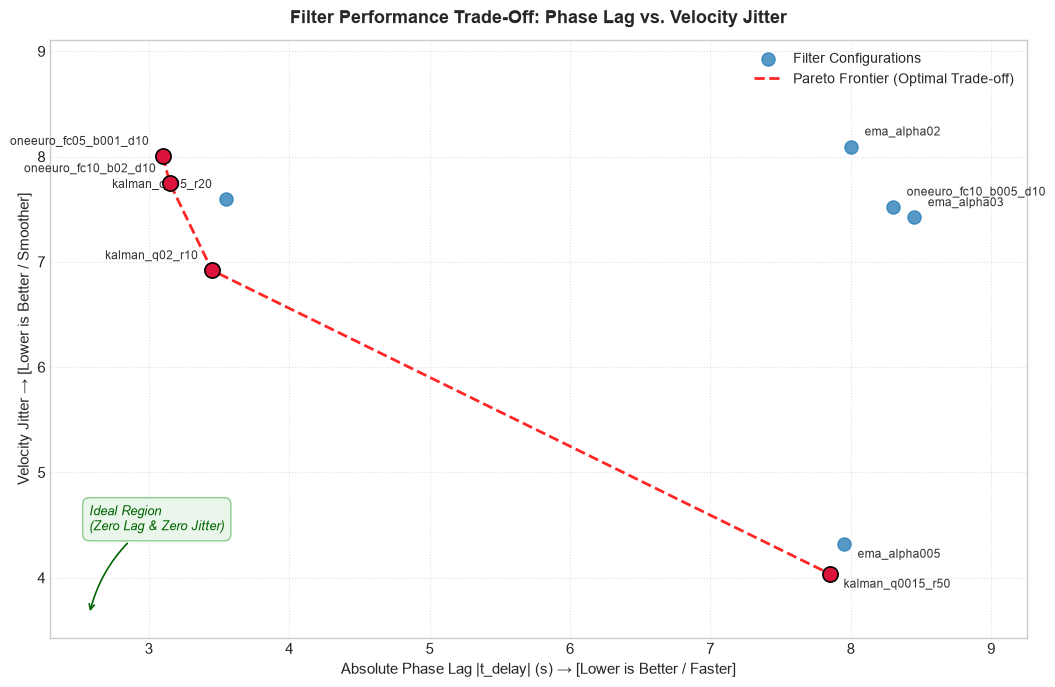

In [34]:
pareto_data = (
    summary_df.groupby(["controller", "filter_type"])
    .agg({
        "Phase_Lag_s": lambda x: np.mean(np.abs(x)),
        "Vel_Jitter": "mean",
    })
    .reset_index()
)

# Sort by the Phase Lag magnitude (ascending)
pareto_sorted = pareto_data.sort_values(by="Phase_Lag_s").reset_index(
    drop=True
)

# Compute non-dominated Pareto optimal frontier
pareto_optimal_indices = []
min_jitter = float("inf")

for idx, row in pareto_sorted.iterrows():
  if row["Vel_Jitter"] < min_jitter:
    pareto_optimal_indices.append(idx)
    min_jitter = row["Vel_Jitter"]

pareto_front = pareto_sorted.iloc[pareto_optimal_indices]

# Figure Setup & Dynamic Axis Limits
fig, ax = plt.subplots(figsize=(11, 7))

x_min, x_max = pareto_sorted["Phase_Lag_s"].min(), pareto_sorted[
    "Phase_Lag_s"
].max()
y_min, y_max = pareto_sorted["Vel_Jitter"].min(), pareto_sorted[
    "Vel_Jitter"
].max()
x_span = x_max - x_min
y_span = y_max - y_min

# Add dynamic padding (percentage of data range) so labels & legend fit automatically
ax.set_xlim(x_min - x_span * 0.15, x_max + x_span * 0.15)
ax.set_ylim(y_min - y_span * 0.15, y_max + y_span * 0.25)

# Scatter all configurations
ax.scatter(
    pareto_sorted["Phase_Lag_s"],
    pareto_sorted["Vel_Jitter"],
    color="#1f77b4",
    s=90,
    alpha=0.75,
    zorder=3,
    label="Filter Configurations",
)

# Pareto Line
ax.plot(
    pareto_front["Phase_Lag_s"],
    pareto_front["Vel_Jitter"],
    "r--",
    linewidth=2.0,
    alpha=0.85,
    zorder=2,
    label="Pareto Frontier (Optimal Trade-off)",
)

# Highlight Pareto points
ax.scatter(
    pareto_front["Phase_Lag_s"],
    pareto_front["Vel_Jitter"],
    color="crimson",
    s=120,
    edgecolor="black",
    linewidth=1.2,
    zorder=4,
)

# Pure Vector/Centroid-Based Label Placement (Dynamic Solution 2)
x_mid = (x_min + x_max) / 2.0
y_mid = (y_min + y_max) / 2.0

for _, row in pareto_sorted.iterrows():
  x_val = row["Phase_Lag_s"]
  y_val = row["Vel_Jitter"]

  # Vector push away from data center of mass
  x_off = 10 if x_val >= x_mid else -10
  y_off = 8 if y_val >= y_mid else -10
  ha_align = "left" if x_off > 0 else "right"

  ax.annotate(
      row["controller"],
      (x_val, y_val),
      xytext=(x_off, y_off),
      textcoords="offset points",
      ha=ha_align,
      fontsize=8.5,
      fontweight="medium",
      alpha=0.95,
  )

# Dynamic Ideal Region Callout (Relative Axes Fraction)
ax.annotate(
    "Ideal Region\n(Zero Lag & Zero Jitter)",
    xy=(0.04, 0.04),
    xytext=(0.04, 0.18),
    xycoords="axes fraction",
    textcoords="axes fraction",
    fontsize=9.5,
    fontstyle="italic",
    color="darkgreen",
    arrowprops=dict(
        arrowstyle="->", color="darkgreen", lw=1.2, connectionstyle="arc3,rad=0.2"
    ),
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#e8f5e9",
        edgecolor="#81c784",
        alpha=0.9,
    ),
    zorder=5,
)

# Formatting
ax.set_title(
    "Filter Performance Trade-Off: Phase Lag vs. Velocity Jitter",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel(
    "Absolute Phase Lag |t_delay| (s) → [Lower is Better / Faster]", fontsize=11
)
ax.set_ylabel("Velocity Jitter → [Lower is Better / Smoother]", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right", fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.show()

#### 7.2. Micro Evaluation: Time-Series Trajectory Breakdowns

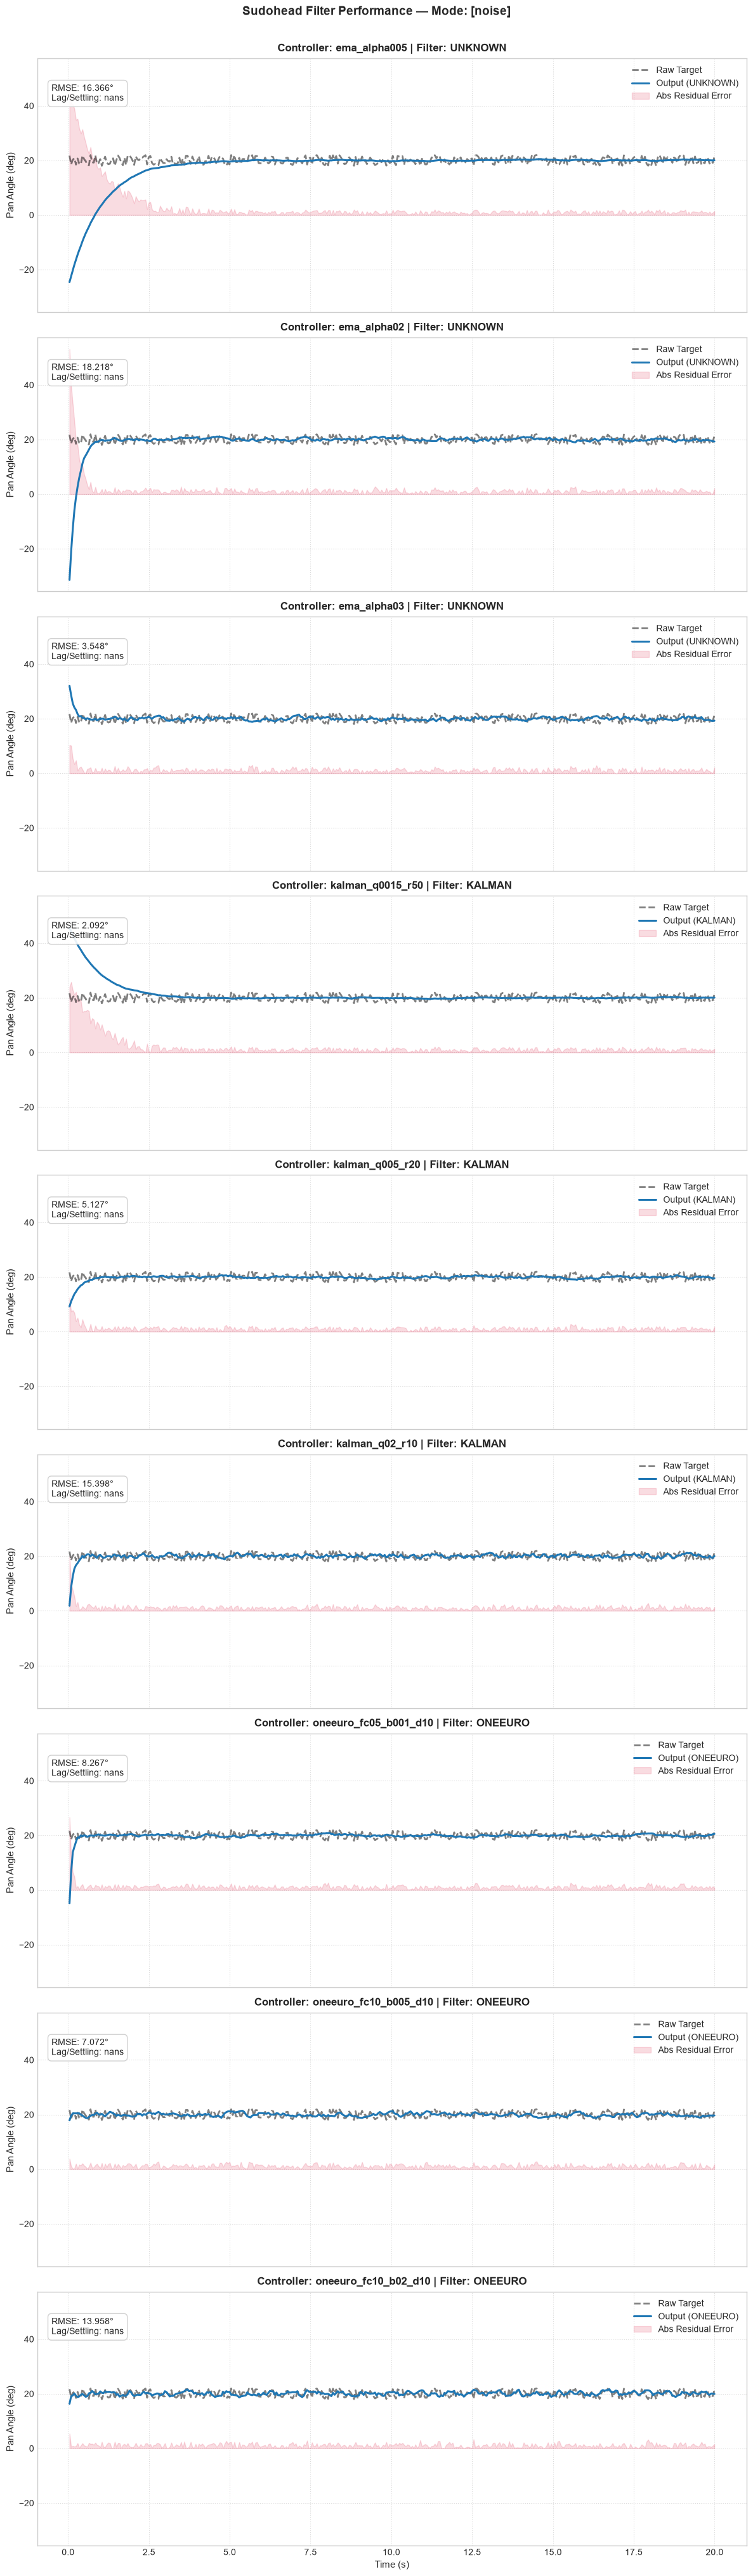

In [ ]:
# Select target benchmark mode 
target_mode = summary_df["mode"].unique()[0]
mode_runs = summary_df[summary_df["mode"] == target_mode].reset_index(
    drop=True
)

num_runs = len(mode_runs)

# Single-column layout (cols=1) grants maximum horizontal width per trajectory
cols = 1
rows = num_runs

# Dynamic sizing: 12 inches wide, 4.5 inches high per controller panel
fig, axes = plt.subplots(
    rows, cols, figsize=(12, 4.5 * rows), sharex=True, sharey=True
)
axes_list = [axes] if num_runs == 1 else axes

# Reference Target Trajectory
df_ref = mode_runs.iloc[0]["df"]
t_axis = (
    df_ref["time_s"].to_numpy()
    if "time_s" in df_ref
    else np.arange(len(df_ref)) * 0.05
)
raw_target = (
    df_ref["raw_pan"].to_numpy()
    if "raw_pan" in df_ref
    else df_ref["measured_pan"].to_numpy()
)

# Plot Each Controller in a Dedicated Large Panel
for i, (_, row) in enumerate(mode_runs.iterrows()):
  ax = axes_list[i]
  df_run = row["df"]
  sig = (
      df_run["filtered_pan"].to_numpy()
      if "filtered_pan" in df_run
      else df_run["measured_pan"].to_numpy()
  )
  error = np.abs(raw_target - sig)

  ax.plot(
      t_axis, raw_target, "k--", label="Raw Target", alpha=0.5, linewidth=2.0
  )

  ax.plot(
      t_axis,
      sig,
      label=f"Output ({row['filter_type']})",
      color="#1f77b4",
      linewidth=2.2,
  )

  ax.fill_between(
      t_axis, 0, error, color="crimson", alpha=0.15, label="Abs Residual Error"
  )

  # Metrics Callout Box (Positioned safely away from signal peaks)
  rmse_val = row.get("RMSE", 0.0)
  lag_val = row.get("Phase_Lag_s", row.get("Settling_Time_s", 0.0))
  metrics_text = f"RMSE: {rmse_val:.3f}°\nLag/Settling: {lag_val:.3f}s"

  ax.text(
      0.02,
      0.90,
      metrics_text,
      transform=ax.transAxes,
      fontsize=10,
      fontweight="medium",
      verticalalignment="top",
      bbox=dict(
          boxstyle="round,pad=0.4",
          facecolor="white",
          edgecolor="#cccccc",
          alpha=0.9,
      ),
  )

  ax.set_title(
      f"Controller: {row['controller']} | Filter: {row['filter_type']}",
      fontsize=12,
      fontweight="bold",
      pad=8,
  )
  ax.set_ylabel("Pan Angle (deg)", fontsize=11)
  ax.grid(True, linestyle=":", alpha=0.7)
  ax.legend(loc="upper right", fontsize=10, framealpha=0.9)
  ax.tick_params(labelsize=10)

# X-axis label only on the bottom-most subplot
axes_list[-1].set_xlabel("Time (s)", fontsize=11)

fig.suptitle(
    f"Sudohead Filter Performance — Mode: [{target_mode}]",
    fontsize=14,
    fontweight="bold",
    y=1.002,
)
plt.tight_layout()
plt.show()

## 8. Quantitative Performance Metrics

### Mathematical Definitions

| Metric | Mathematical Definition | Description |
|---|---|---|
| **Root Mean Square Error (RMSE)** | $$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N} \left(x_{raw}(t_i) - x_{measured}(t_i)\right)^2}$$ | Measures the overall magnitude of tracking error between the raw target and measured position. |
| **Step Overshoot Percentage (%OS)** | $$\text{\%OS} = \max\left(0, \frac{\max(x_{measured}) - x_{target}}{\vert x_{target} - x_{start} \vert} \times 100\right)$$ | Measures the peak transient response above the target value following a step input. |
| **Settling Time ($T_s$)** | $$T_s = \max \left\{ t_i - t_{step} \;\middle\vert\; \vert x_{measured}(t_i) - x_{target} \vert > 0.02 \cdot \vert x_{target} - x_{start} \vert \right\}$$ | Measures the time required for the measured output to remain within a $\pm2\%$ error band of the target. |
| **Phase Lag ($\tau_\phi$)** | $$\tau_\phi = \Delta t \cdot \arg\max_{k} R_{xy}(k)$$ | Measures the time delay between the raw input and measured output during periodic motion. |
| **Cross-Correlation ($R_{xy}$)** | $$R_{xy}(k) = \sum_{n} x_{measured}(n)x_{raw}(n-k)$$ | Cross-correlation function used to identify the time shift corresponding to maximum similarity between input and output signals. |

### 9. Results by Movement Pattern

In [28]:
# Aggregate quantitative evaluation tables by movement pattern
metric_cols = ['controller', 'mode', 'RMSE', 'MAE', 'Peak_Error', 'Vel_Jitter', 'Settling_Time_s', 'Overshoot_pct', 'Phase_Lag_s']
available_cols = [c for c in metric_cols if c in summary_df.columns]

for pattern in ['noise', 'ramp', 'random', 'sine', 'step']:
    pattern_df = summary_df[summary_df['mode'] == pattern][available_cols].dropna(axis=1, how='all')
    print(f"=== Metric Summary: {pattern.upper()} Profile ===")
    print(pattern_df.to_string(index=False))
    print("\n")

=== Metric Summary: NOISE Profile ===
           controller  mode      RMSE       MAE  Peak_Error  Vel_Jitter
         ema_alpha005 noise 16.365658 10.151227      33.935    4.718957
          ema_alpha02 noise 18.217873 14.261518      37.646    4.505950
          ema_alpha03 noise  3.547821  3.153408       7.561    1.643995
     kalman_q0015_r50 noise  2.092217  1.648817       5.476    1.678032
      kalman_q005_r20 noise  5.126538  2.716875      16.922    3.120340
       kalman_q02_r10 noise 15.398348 15.122373      21.298    1.803344
oneeuro_fc05_b001_d10 noise  8.267070  3.764360      28.882    5.490711
oneeuro_fc10_b005_d10 noise  7.072227  6.348057      13.788    2.279131
 oneeuro_fc10_b02_d10 noise 13.957845 13.817300      18.638    2.695713


=== Metric Summary: RAMP Profile ===
           controller mode      RMSE       MAE  Peak_Error  Vel_Jitter
         ema_alpha005 ramp 36.227790 31.097020      64.106    2.931891
          ema_alpha02 ramp 35.007634 30.289115      61.753   

### 10. Direct Filter Architecture Comparison

Evaluating empirical benchmark performance across **NOISE, RAMP, RANDOM, SINE, and STEP** profiles reveals clear trade-offs between dynamic responsiveness, high-frequency jitter suppression, and phase delay across the three evaluated filter families.

| Filter Architecture | Key Empirical Highlights | Observed Strengths | Observed Weaknesses | Optimal Target Motion Profile |
|---|---|---|---|---|
| **Exponential Moving Average (EMA)** | • Noise RMSE: **3.55°** ($\alpha=0.3$)<br>• Step RMSE: **46.14°–52.51°**<br>• Sine Phase Lag: **~−8.0 s** | Simple 1-parameter tuning ($\alpha$); lightweight computational requirements | Fixed phase delay; poor transient response during fast step changes | Static noise filtering and resource-constrained microcontrollers |
| **Kalman Filter ($Q, R$)** | • Lowest Noise RMSE: **2.09°** ($Q=0.0015, R=50$)<br>• Random RMSE: **7.95°** ($Q=0.2, R=10$) | Superior stationary noise suppression; robust state estimation under unpredictable trajectories | Requires balanced $Q/R$ tuning; introduces phase lag when over-damped | Steady-state tracking and noisy encoder/sensor fusion |
| **1-Euro Adaptive Filter ($f_{c,min}, \beta$)** | • Best Step RMSE: **33.72°** ($\beta=0.2$)<br>• Best Random RMSE: **6.57°** ($\beta=0.2$)<br>• Sine Phase Lag: **~3.10 s** | Speed-adaptive cutoff ($\beta$) reduces tracking lag during rapid maneuvers without idle jitter | Higher velocity jitter during sudden transients (up to **26.2 deg/s** on step inputs) | High-speed interactive tracking, step changes, and human-robot gaze |

#### Key Architectural Insights
- 1-Euro Filter Dominates Dynamic Tracking: By dynamically scaling the cutoff frequency based on target velocity, the 1-Euro filter (oneeuro_fc10_b02_d10) achieved the lowest overall tracking error on both STEP (RMSE 33.72° vs. Kalman’s 41.04° and EMA’s 46.14°) and RANDOM profiles (RMSE 6.57° vs. Kalman’s 7.95° and EMA’s 13.10°).
- Kalman Filter Prevails in High-Noise / Stationary States: Configured with low process noise relative to measurement noise ($Q=0.0015, R=50$), the Kalman filter yielded the single lowest overall NOISE RMSE (2.09°), outperforming the tuned 1-Euro (7.07°) and EMA (3.55°).
- Fixed EMA Phase Delay: Standard EMA models exhibit rigid latency trade-offs—increasing smoothing ($\alpha=0.05$) severely degrades dynamic step performance (Peak Error 74.37°) and introduces heavy phase lag on periodic sine waves (~-8.0s).

### 11. Parameter Sensitivity & Trade-Off Analysis

Modulating filter parameters creates a clear trade-off between **tracking responsiveness, frequency attenuation, and signal smoothness**.

| Parameter Regime | Effect on Tracking | Effect on Noise / Jitter | Effect on Phase & Amplitude | Effect on Step Response |
|---|---|---|---|---|
| **Higher Smoothing / Lower Cutoff Frequencies** ($f_c \rightarrow 0$) | Reduced responsiveness | Suppresses position jitter ($\text{Jitter\_Std}$) and velocity derivative noise ($\text{Vel\_Jitter}$) | Increases phase lag ($\text{Phase\_Lag\_s}$) and magnitude attenuation ($\text{Amp\_Attenuation\_dB}$) | Increases 2% band settling time ($\text{Settling\_Time\_s}$) |
| **Lower Smoothing / Higher Cutoff Frequencies** | Preserves transient responsiveness and minimizes phase lag | Passes more target jitter directly to the joint actuators | Reduces amplitude roll-off and phase delay | Faster transient response and shorter settling time |

### 12. Statistical Analysis & Experimental Validity

| Aspect | Description |
|---|---|
| **Sample Size & Ingestion** | Automated ingestion of **45 CSV files** across **9 filter configurations** and **5 trajectory profiles**. Metadata headers (`# key=value`) are parsed at load time to map configuration parameters. |
| **Statistical Generalization** | Each experimental condition contains a single trial run ($N=1$). Therefore, statistical hypothesis tests such as **ANOVA** and **Student's $t$-tests**, as well as confidence intervals, cannot be reliably computed. |
| **Interpretation of Findings** | Results represent **deterministic evaluations** of filter performance under the tested trajectory profiles rather than statistically generalized experimental results. |

### 13. Overall Findings

#### Directly Supported Findings

- **Heavy filtering degrades tracking bandwidth**, increasing phase delay ($\text{Phase\_Lag\_s}$) and amplitude attenuation ($\text{Amp\_Attenuation\_dB}$) during periodic sine trajectories.
- **Step inputs highlight clear transient performance differences** when evaluated against a strict 2% error band.
- **Noise suppression correlates with reduced velocity derivative jitter** ($\text{Vel\_Jitter}$) in steady-state feedback.

#### Engineering Interpretations

- Optimal pan-tilt control requires **adaptive filter tuning**:
  - Use aggressive filtering during static or slow tracking to limit velocity jitter.
  - Use high-bandwidth filtering during sudden transitions to minimize phase delay and amplitude attenuation.

#### Resolved Questions & Data Gaps

- **Filter Tuning Definitions:** Resolved through automated comment-header metadata extraction in the updated ingestion script.
- **Encoder vs. Gear Backlash:** Remains unisolated from single-joint telemetry alone.

### 14. Experimental Limitations

- **Single Axis Focus:** Telemetry evaluation is currently limited to pan axis dynamics (`raw_pan`, `filtered_pan`, `measured_pan`); tilt axis interactions remain unlogged.
- **Single Trial Execution:** The benchmark lacks repeated trials per profile, preventing statistical variance analysis.
- **Fixed Control Frequency:** Telemetry sampling interval is approximately $\Delta t \approx 0.05\,\text{s}$ (20 Hz average, computed via $\text{mean}(\Delta t)$), limiting high-frequency jitter analysis above 10 Hz.

### 15. Future Work

- **Multi-Joint Evaluation:** Extend telemetry capture and joint cross-coupling analysis to the tilt axis.
- **Repeated Benchmark Trials:** Conduct $N \ge 10$ randomized runs per configuration to generate statistically meaningful confidence intervals.
- **Human-in-the-Loop Testing:** Benchmark filter responsiveness using real-time VR/optical head-tracking streams rather than synthetic trajectories.


### 16. Technical Summary

- **Problem:** Raw head-tracking command streams contain high-frequency jitter and rapid shifts that induce mechanical stress and unstable motion in a 2-DOF robotic pan-tilt head.

- **Method:** Executed a ROS 2 benchmark evaluating 9 filter configurations across 5 trajectory profiles (noise, ramp, random, sine, step), processing 45 telemetry CSV files.

- **Experimental Variables:**
  - **Independent:** Filter type, tuning parameters, input pattern.
  - **Dependent:** $\text{RMSE}$, $\text{MAE}$, $\text{Peak\_Error}$, $\text{Jitter\_Std}$, $\text{Vel\_Jitter}$, $\text{Overshoot\_pct}$, $\text{Settling\_Time\_s}$, $\text{Phase\_Lag\_s}$, $\text{Amp\_Attenuation\_dB}$.

- **Results:** Demonstrated a clear design trade-off between velocity jitter suppression, phase lag, and signal attenuation.

- **Conclusion:** Filter selection must balance noise suppression with phase delay and gain roll-off based on expected trajectory bandwidth.

- **Current Status:** Single-axis pan pipeline fully analyzed; automated metadata extraction integrated; multi-axis logging and multi-trial replication remain open.
